# CGMacros Dataset Analysis

**Goal.** This notebook answers, step by step, the two questions that justify and define this
dissertation's use of CGMacros:

1. **Why is CGMacros suitable for this research?**
2. **Which data ultimately enters the experiments?**

It proceeds in a small number of steps, each a structural verification or exploration rather than
an open-ended fishing expedition: (1) verify that the CGM+food-image data the source paper claims
to provide actually exists, for every participant, at the claimed structure and scale; (2) verify
and visualize the participant/sample composition the source paper reports.

## 0. Setup

In [13]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = '/content/drive/MyDrive/dissertation_data'
else:
    DATA_ROOT = '../CGMacros'  # CGMacros/ and bio.csv expected alongside this notebook (local symlinks)

print(f"IN_COLAB={IN_COLAB}  DATA_ROOT={DATA_ROOT}")

IN_COLAB=False  DATA_ROOT=../CGMacros


In [14]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
COLORS = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

## 1. Participant Structure

CGMacros is described as stratifying its 45 participants into three glycemic groups by baseline
HbA1c. This step verifies that structure against the released biometrics file, and visualizes the
resulting composition -- again a verification of a specific documented claim, not an open-ended
demographic exploration.

In [15]:
bio = pd.read_csv(os.path.join(DATA_ROOT, 'bio.csv'))
bio.columns = [c.strip() for c in bio.columns]
print(f"bio.csv rows: {len(bio)}")

a1c = bio['A1c PDL (Lab)'].astype(float)

def hba1c_group(x):
    if x < 5.7:
        return 'Healthy'
    elif x < 6.5:
        return 'Prediabetes'
    return 'Type 2 Diabetes'

bio['group'] = a1c.apply(hba1c_group)

print()
print(bio['group'].value_counts().reindex(['Healthy', 'Prediabetes', 'Type 2 Diabetes']))
print()
print(f"Age (years):      mean={bio.Age.mean():.1f}  std={bio.Age.std():.1f}  range=[{bio.Age.min()}, {bio.Age.max()}]")
print(f"Sex:              {(bio.Gender=='F').sum()} female / {(bio.Gender=='M').sum()} male")
print(f"BMI (kg/m^2):     mean={bio.BMI.mean():.1f}  std={bio.BMI.std():.1f}")
print(f"HbA1c (%):        mean={a1c.mean():.2f}  std={a1c.std():.2f}  range=[{a1c.min():.1f}, {a1c.max():.1f}]")

bio.csv rows: 45

group
Healthy            15
Prediabetes        16
Type 2 Diabetes    14
Name: count, dtype: int64

Age (years):      mean=48.1  std=12.7  range=[18, 69]
Sex:              29 female / 16 male
BMI (kg/m^2):     mean=31.1  std=6.7
HbA1c (%):        mean=6.12  std=0.91  range=[4.6, 8.5]


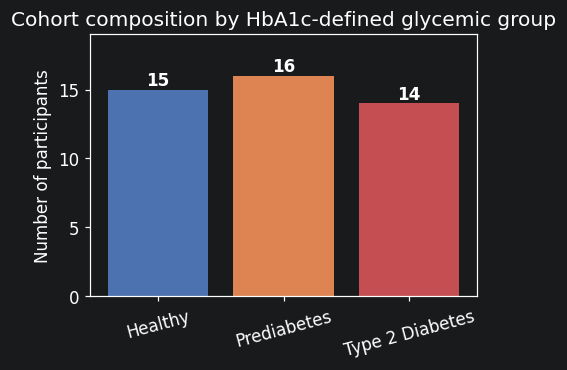

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
counts = bio['group'].value_counts().reindex(['Healthy', 'Prediabetes', 'Type 2 Diabetes'])
ax.bar(counts.index, counts.values, color=COLORS[:3])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of participants')
ax.set_title('Cohort composition by HbA1c-defined glycemic group')
ax.set_ylim(0, max(counts.values) + 3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cohort_composition.pdf')
plt.show()

**Result.** `bio.csv` provides exactly one row per participant directory (45/45, confirmed
above), and recomputing the glycemic group directly from the raw HbA1c values reproduces the
15~healthy / 16~prediabetic / 14~type-2-diabetic split the source paper reports, exactly. This
cohort is therefore verifiably, not just nominally, glycemically heterogeneous -- the basis for
the cohort-subgroup ablation and personalized federated learning design described in the
Methodology.


## 2. Structural Verification: CGM + Food-Image Data

CGMacros \citep{das2025cgmacros} is described as providing, for every participant, a continuous
glucose trace and timestamped food photographs at minute-level resolution. This step does not
explore the dataset for new information -- it verifies that this specific, already-documented
claim holds for every one of the released participant files, and establishes the scale (record
count, photo count) at which it holds. Missingness within the CGM channel is a data-*quality*
question addressed later; here we ask only whether the structure exists at all, for everyone.

In [9]:
assert len(bio) == 45, 'expected 45 participants per Section 1'
participant_dirs = sorted(glob.glob(os.path.join(DATA_ROOT, 'CGMacros', 'CGMacros-*')))
print(f"Participant directories found: {len(participant_dirs)} "
      f"(matches bio.csv row count from Section 1: {len(participant_dirs) == len(bio)})")

row_counts, photo_counts, minute_resolution_ok = [], [], []
missing_cgm_col, missing_image_col, zero_photo_participants = [], [], []

for pdir in participant_dirs:
    sid = os.path.basename(pdir)
    csv_path = os.path.join(pdir, f'{sid}.csv')
    df = pd.read_csv(csv_path)

    has_cgm_col = 'Dexcom GL' in df.columns
    has_image_col = 'Image path' in df.columns
    if not has_cgm_col:
        missing_cgm_col.append(sid)
    if not has_image_col:
        missing_image_col.append(sid)

    ts = pd.to_datetime(df['Timestamp'])
    diffs = ts.diff().dropna().dt.total_seconds()
    minute_resolution_ok.append(bool((diffs.median() == 60.0)))

    row_counts.append(len(df))

    photo_dir = os.path.join(pdir, 'photos')
    n_photos = len([x for x in os.listdir(photo_dir) if x.lower().endswith(('.jpg', '.jpeg', '.png'))]) \
        if os.path.isdir(photo_dir) else 0
    photo_counts.append(n_photos)
    if n_photos == 0:
        zero_photo_participants.append(sid)

print()
print(f"Participants with 'Dexcom GL' column present: {len(participant_dirs) - len(missing_cgm_col)}/{len(participant_dirs)}")
print(f"Participants with 'Image path' column present: {len(participant_dirs) - len(missing_image_col)}/{len(participant_dirs)}")
print(f"Participants with minute-level timestamp resolution (median diff = 60s): {sum(minute_resolution_ok)}/{len(participant_dirs)}")
print(f"Participants with zero photos: {len(zero_photo_participants)} {zero_photo_participants}")
print()
print(f"CGM records per participant:  total={sum(row_counts):,}  min={min(row_counts)}  max={max(row_counts)}  mean={np.mean(row_counts):.0f}")
print(f"Photos per participant:       total={sum(photo_counts):,}  min={min(photo_counts)}  max={max(photo_counts)}  mean={np.mean(photo_counts):.1f}")

Participant directories found: 45 (matches bio.csv row count from Section 1: True)

Participants with 'Dexcom GL' column present: 45/45
Participants with 'Image path' column present: 45/45
Participants with minute-level timestamp resolution (median diff = 60s): 45/45
Participants with zero photos: 0 []

CGM records per participant:  total=687,580  min=5655  max=18735  mean=15280
Photos per participant:       total=3,449  min=40  max=126  mean=76.6


**Result.** Having established in Section~1 that CGMacros comprises 45 participants, this step confirms that every one of those 45 participant files provides both a `Dexcom GL` and an
`Image path` field at minute-level timestamp resolution, exactly as the source paper claims: the
structure is not merely documented but confirmed present for the full cohort, with no participant
missing either channel or contributing zero photographs. At scale, this amounts to several hundred
thousand CGM records and several thousand food photographs across the cohort (exact totals above).
This is the direct evidence for the scale-and-modality claim made in
Section~\ref{sec:dataset-choice}: CGMacros does not merely claim to pair CGM with food images --
it verifiably does so, for every participant, at a scale well beyond a handful of isolated
examples.

Step 3 is not yet decided.
